# DINOv2 + AnyUp on Vehicle-Centered Crops

Updated workflow:
1. Read vehicle polygons from `data/record_pairs/*.json`
2. Sample 8 random vehicle instances
3. Build center crops around each vehicle (from polygon center)
4. Run DINOv2 + AnyUp sequentially (no batching)
5. Fit PCA and KMeans per crop
6. Visualize original crop, PCA-RGB image, and dense KMeans image


In [10]:
from pathlib import Path
import json
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision.transforms as T
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.style.use('ggplot')


In [11]:
# Config
repo_root = Path.cwd()
data_dir = repo_root / 'data' / 'record_pairs'
assert data_dir.exists(), f'Missing directory: {data_dir}'

num_crops = 8
crop_size = 224
k_clusters = 20
label_name = 'vehicle'

print('data_dir:', data_dir)
print('num_crops:', num_crops)
print('crop_size:', crop_size)
print('k_clusters:', k_clusters)


data_dir: /home/schelli/git/wtcv/data/record_pairs
num_crops: 8
crop_size: 224
k_clusters: 20


In [12]:
# Collect vehicle instances from LabelMe JSON
instances = []
json_files = sorted(data_dir.glob('*.json'))

for jf in json_files:
    d = json.loads(jf.read_text())
    shapes = d.get('shapes', []) or []
    img_path = data_dir / (jf.stem + '.png')
    if not img_path.exists():
        continue

    for si, s in enumerate(shapes):
        if s.get('label') != label_name:
            continue
        pts = s.get('points') or []
        if len(pts) < 3:
            continue

        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]

        cx = float(sum(xs) / len(xs))
        cy = float(sum(ys) / len(ys))

        instances.append({
            'json_file': jf.name,
            'image_file': img_path.name,
            'image_path': str(img_path),
            'shape_index': si,
            'center_x': cx,
            'center_y': cy,
        })

assert len(instances) >= num_crops, f'Need at least {num_crops} vehicle instances, found {len(instances)}'
print('total_vehicle_instances:', len(instances))


total_vehicle_instances: 338


In [13]:
# Sample random vehicle instances and create center crops
selected = random.sample(instances, num_crops)


def center_crop_with_pad(pil_img, cx, cy, size):
    w, h = pil_img.size
    half = size // 2

    # integer center
    cx_i, cy_i = int(round(cx)), int(round(cy))

    x0 = cx_i - half
    y0 = cy_i - half
    x1 = x0 + size
    y1 = y0 + size

    # Amount of padding needed on each side
    pad_left = max(0, -x0)
    pad_top = max(0, -y0)
    pad_right = max(0, x1 - w)
    pad_bottom = max(0, y1 - h)

    # Clamp crop window to image bounds
    sx0 = max(0, x0)
    sy0 = max(0, y0)
    sx1 = min(w, x1)
    sy1 = min(h, y1)

    crop = pil_img.crop((sx0, sy0, sx1, sy1))

    if pad_left or pad_top or pad_right or pad_bottom:
        out = Image.new('RGB', (size, size), color=(0, 0, 0))
        out.paste(crop, (pad_left, pad_top))
        return out

    return crop

crop_items = []
for item in selected:
    img = Image.open(item['image_path']).convert('RGB')
    crop = center_crop_with_pad(img, item['center_x'], item['center_y'], crop_size)
    crop_items.append({
        'meta': item,
        'crop': crop,
    })

print('created_crops:', len(crop_items))
for c in crop_items:
    m = c['meta']
    print(f" - {m['image_file']} shape#{m['shape_index']} center=({m['center_x']:.1f},{m['center_y']:.1f})")


created_crops: 8
 - 001458.png shape#0 center=(643.6,242.6)
 - 000203.png shape#1 center=(913.5,301.6)
 - 000076.png shape#0 center=(821.9,321.1)
 - 000501.png shape#0 center=(523.2,303.3)
 - 000462.png shape#0 center=(564.8,339.5)
 - 000385.png shape#0 center=(358.7,340.2)
 - 000216.png shape#0 center=(329.3,310.2)
 - 000197.png shape#1 center=(633.8,338.8)


In [14]:
# Models
# In your base conda environment this should use CUDA.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').eval().to(device)
anyup = torch.hub.load('wimmerth/anyup', 'anyup', trust_repo=True).eval().to(device)

print(type(dino).__name__, type(anyup).__name__)


device: cuda


Using cache found in /home/schelli/.cache/torch/hub/facebookresearch_dinov2_main


DinoVisionTransformer AnyUp


Using cache found in /home/schelli/.cache/torch/hub/wimmerth_anyup_main


In [15]:
# Preprocess helper
transform = T.Compose([
    T.Resize((crop_size, crop_size)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])


In [16]:
# Sequential per-crop pipeline (no batching): DINO -> AnyUp -> PCA/KMeans per crop
results = []

for item in crop_items:
    meta = item['meta']
    crop = item['crop']

    x = transform(crop).unsqueeze(0).to(device)

    with torch.no_grad():
        feats = dino.forward_features(x)
        patch_tokens = feats['x_norm_patchtokens']  # (1, N, C)

        _, n, c = patch_tokens.shape
        h = w = int(n ** 0.5)
        assert h * w == n, f'Patch token count {n} is not a square.'

        lowres_map = patch_tokens.transpose(1, 2).reshape(1, c, h, w)
        up_map = anyup(x, lowres_map)[0]  # (C, H, W)

    fmap = up_map.detach().cpu().numpy()          # (C, H, W)
    c_dim, H, W = fmap.shape
    tokens = fmap.reshape(c_dim, H * W).T         # (H*W, C)

    # PCA per crop
    pca = PCA(n_components=3, random_state=SEED)
    proj = pca.fit_transform(tokens)[:, :3]
    pca_img = proj.reshape(H, W, 3)
    mn = pca_img.min(axis=(0, 1), keepdims=True)
    mx = pca_img.max(axis=(0, 1), keepdims=True)
    pca_img = (pca_img - mn) / (mx - mn + 1e-8)

    # KMeans per crop
    kmeans = KMeans(n_clusters=k_clusters, random_state=SEED, n_init=20)
    labels = kmeans.fit_predict(tokens).reshape(H, W)

    results.append({
        'name': meta['image_file'],
        'shape_index': meta['shape_index'],
        'center': (meta['center_x'], meta['center_y']),
        'crop': crop,
        'pca_img': pca_img,
        'labels': labels,
        'pca_var': pca.explained_variance_ratio_,
    })

    print(f"{meta['image_file']} shape#{meta['shape_index']}: tokens={tokens.shape}, pca_var={pca.explained_variance_ratio_}")


001458.png shape#0: tokens=(50176, 384), pca_var=[0.3150404  0.21814828 0.06957369]
000203.png shape#1: tokens=(50176, 384), pca_var=[0.2807478  0.18202136 0.13592823]
000076.png shape#0: tokens=(50176, 384), pca_var=[0.2386184  0.19701016 0.09983353]
000501.png shape#0: tokens=(50176, 384), pca_var=[0.28482658 0.15845352 0.08674002]
000462.png shape#0: tokens=(50176, 384), pca_var=[0.40042844 0.14256783 0.08090674]
000385.png shape#0: tokens=(50176, 384), pca_var=[0.33361012 0.12889875 0.09653497]
000216.png shape#0: tokens=(50176, 384), pca_var=[0.2822689  0.20481655 0.12275897]
000197.png shape#1: tokens=(50176, 384), pca_var=[0.2790976  0.1860507  0.10938625]


/tmp/ipykernel_163574/387793523.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


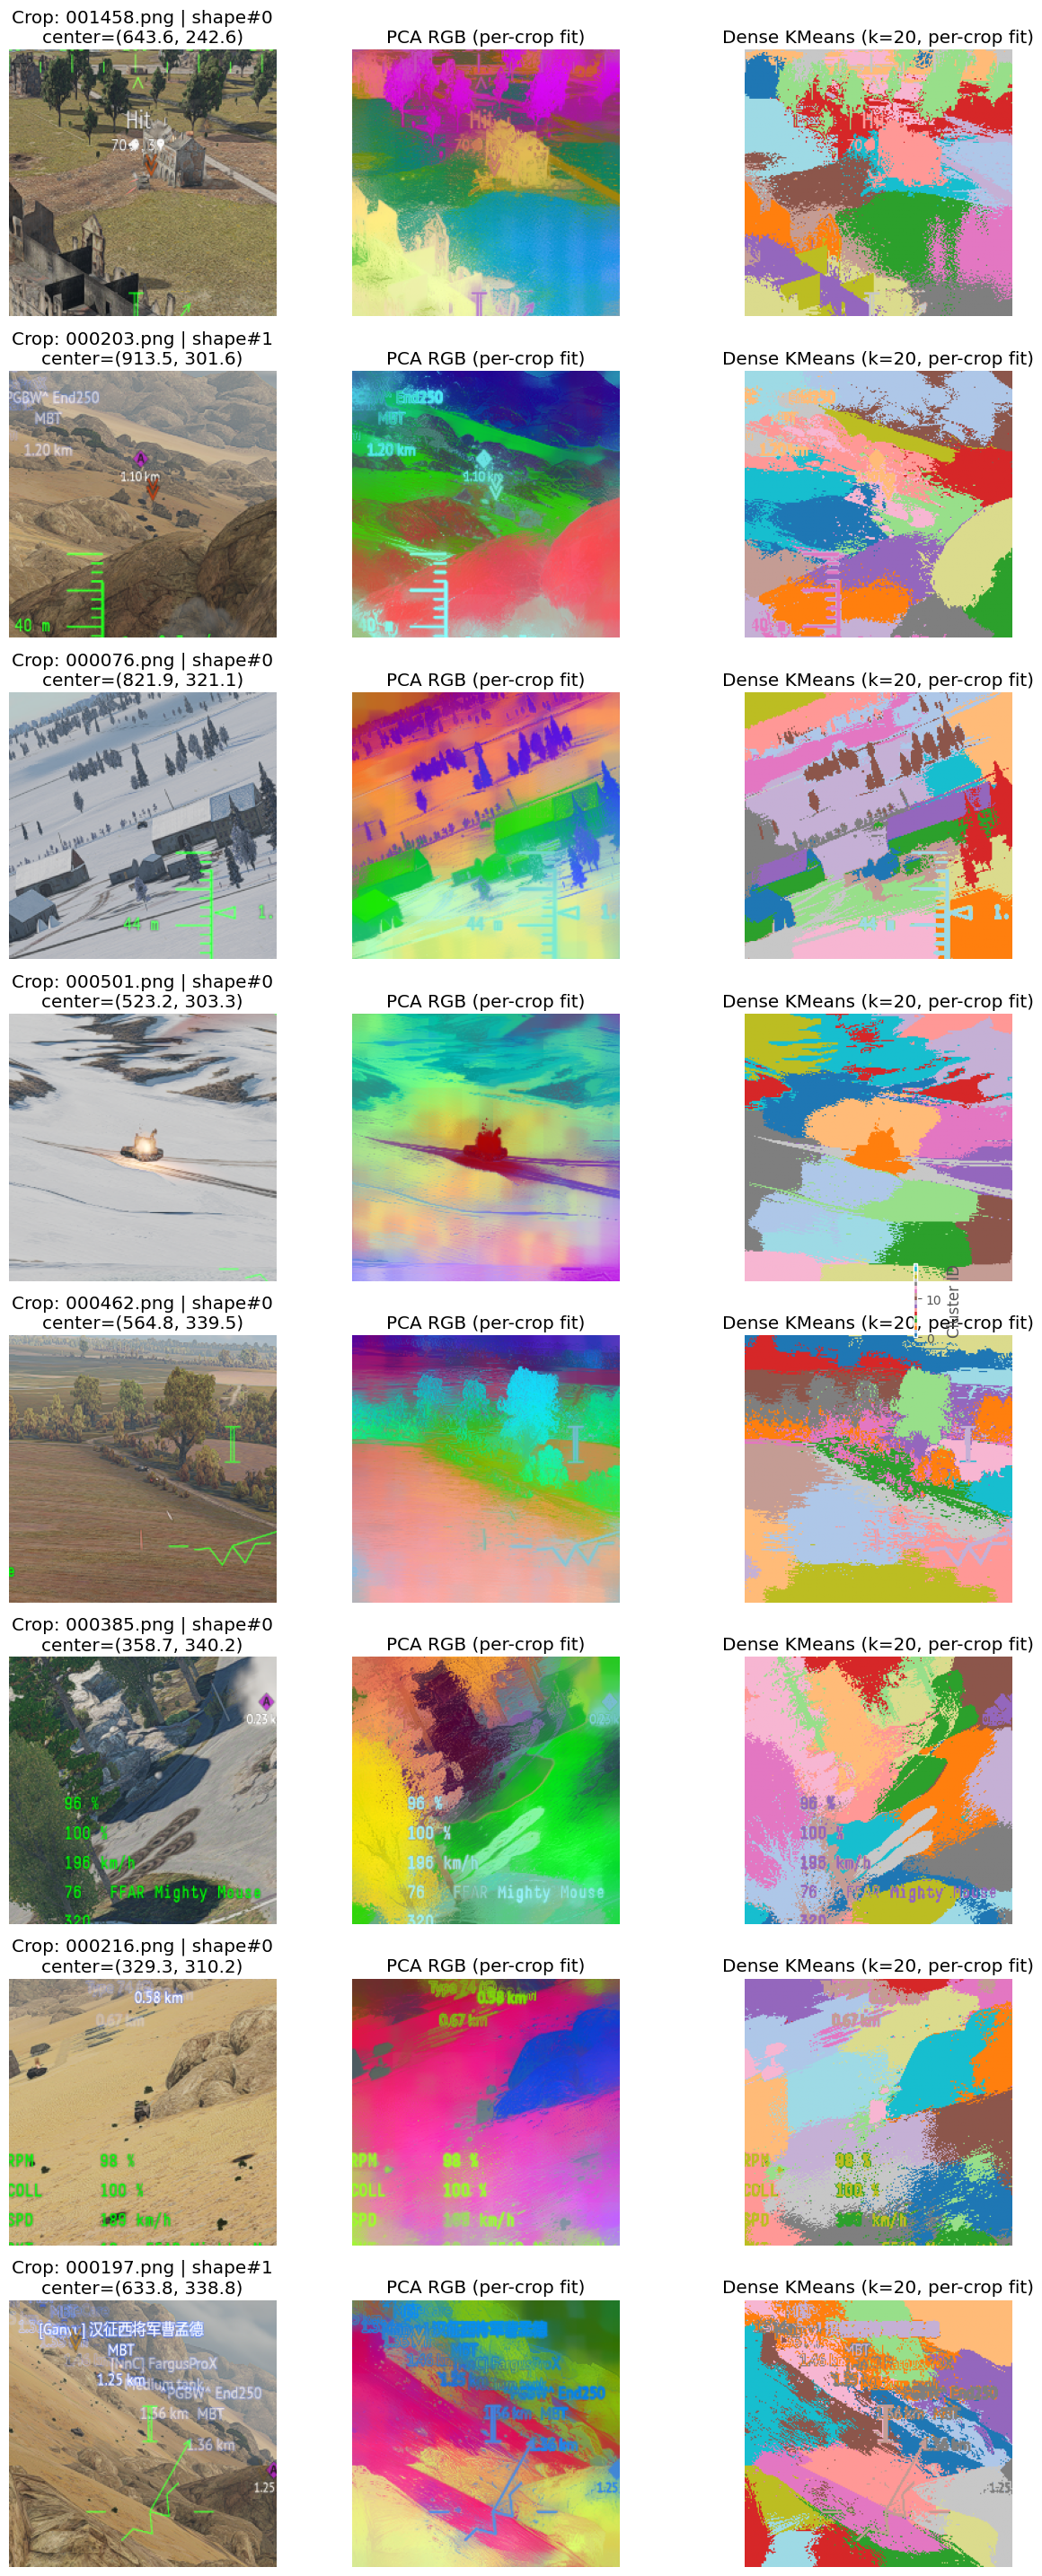

In [19]:
# Visualize crop-level outputs: crop | PCA-RGB | dense KMeans labels
fig, axes = plt.subplots(len(results), 3, figsize=(12, 3.6 * len(results)))
if len(results) == 1:
    axes = np.array([axes])

for r, item in enumerate(results):
    cx, cy = item['center']

    axes[r, 0].imshow(item['crop'])
    axes[r, 0].set_title(f"Crop: {item['name']} | shape#{item['shape_index']}\ncenter=({cx:.1f}, {cy:.1f})")
    axes[r, 0].axis('off')

    axes[r, 1].imshow(item['pca_img'])
    axes[r, 1].set_title('PCA RGB (per-crop fit)')
    axes[r, 1].axis('off')

    im = axes[r, 2].imshow(item['labels'], cmap='tab20', vmin=0, vmax=k_clusters - 1)
    axes[r, 2].set_title(f'Dense KMeans (k={k_clusters}, per-crop fit)')
    axes[r, 2].axis('off')

cbar = fig.colorbar(im, ax=axes[:, 2], fraction=0.015, pad=0.01)
cbar.set_label('Cluster ID')
plt.tight_layout()
plt.show()


In [18]:
# PCA variance summary per crop
for item in results:
    print(f"{item['name']} shape#{item['shape_index']} -> {item['pca_var']}")


001458.png shape#0 -> [0.3150404  0.21814828 0.06957369]
000203.png shape#1 -> [0.2807478  0.18202136 0.13592823]
000076.png shape#0 -> [0.2386184  0.19701016 0.09983353]
000501.png shape#0 -> [0.28482658 0.15845352 0.08674002]
000462.png shape#0 -> [0.40042844 0.14256783 0.08090674]
000385.png shape#0 -> [0.33361012 0.12889875 0.09653497]
000216.png shape#0 -> [0.2822689  0.20481655 0.12275897]
000197.png shape#1 -> [0.2790976  0.1860507  0.10938625]
